### Importing

In [78]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , label_binarize
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , auc , roc_curve

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Drugs.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


### EDA

In [52]:
df.shape

(200, 6)

In [53]:
df.columns = ["Age" , "Sex" , "Blood Pressure" , "Cholesterol Level" , "Sodium to Potassium Ratio" , "Drug"]

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.isnull().sum()

Age                          0
Sex                          0
Blood Pressure               0
Cholesterol Level            0
Sodium to Potassium Ratio    0
Drug                         0
dtype: int64

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        200 non-null    int64  
 1   Sex                        200 non-null    object 
 2   Blood Pressure             200 non-null    object 
 3   Cholesterol Level          200 non-null    object 
 4   Sodium to Potassium Ratio  200 non-null    float64
 5   Drug                       200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.315000,16.544315,15.000,31.0000,45.0000,58.00,74.000
Sodium to Potassium Ratio,200.0,16.084485,7.223956,6.269,10.4455,13.9365,19.38,38.247


In [58]:
df.describe(include = ["object"]).T

,count,unique,top,freq
Sex,200,2,M,104
Blood Pressure,200,3,HIGH,77
Cholesterol Level,200,2,HIGH,103
Drug,200,5,drugY,91


In [59]:
df["Drug"].value_counts()

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [60]:
df["Blood Pressure"].value_counts()

Blood Pressure
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

In [61]:
df["Cholesterol Level"].value_counts()

Cholesterol Level
HIGH      103
NORMAL     97
Name: count, dtype: int64

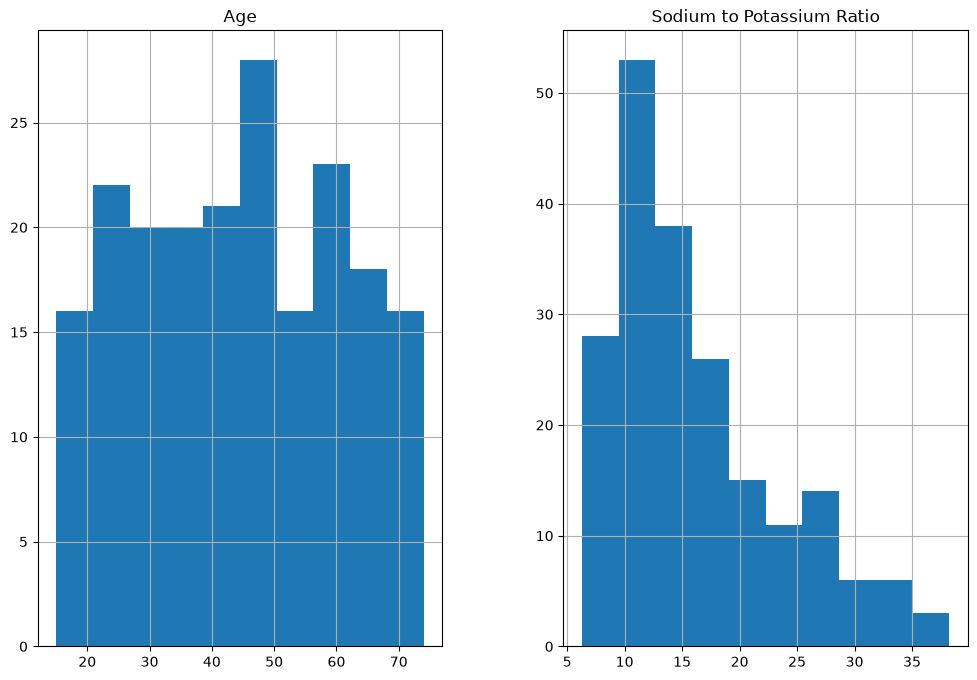

In [62]:
df.hist(figsize = (12 , 8))
plt.show()

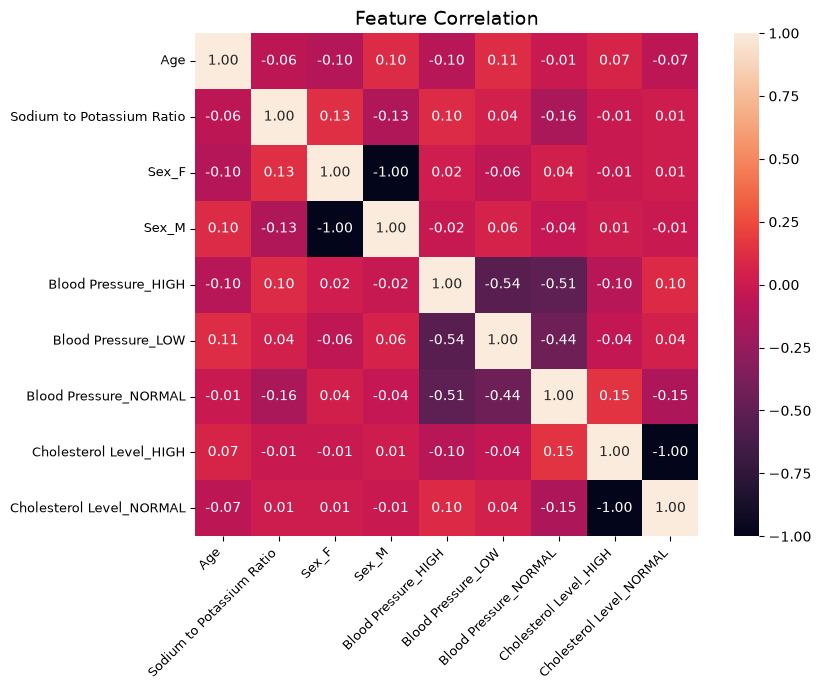

In [63]:
plt.figure(figsize = (9 , 7))
sns.heatmap(pd.get_dummies(df.iloc[: , :-1]).corr() , annot = True , fmt = ".2f" , square = True)

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(rotation = 0 , fontsize = 9)
plt.tight_layout()
plt.show()

### Preprocessing Data

In [64]:
le = LabelEncoder()
cols = ["Sex" , "Cholesterol Level"]

for i in cols:
    df[i] = le.fit_transform(df[i].astype(str))

In [65]:
df["Drug"] = df["Drug"].str.replace("drug" , "" , regex = False)

In [66]:
target = df["Drug"]

In [67]:
df = pd.get_dummies(df.drop(columns = ["Drug"]) , drop_first = False , dtype = int)

### Feature & Target Split

In [68]:
X = df
y = target

### Train & Test Split

In [69]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.18 , stratify = y , random_state = 101)

### Model Training

In [71]:
final_model = DecisionTreeClassifier(criterion = "gini" , random_state = 101)
final_model.fit(X_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",101
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

### Prediction

In [73]:
y_pred = final_model.predict(X_test)

### Evaluation

In [74]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         3
           C       1.00      1.00      1.00         3
           X       1.00      1.00      1.00        10
           Y       1.00      1.00      1.00        16

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



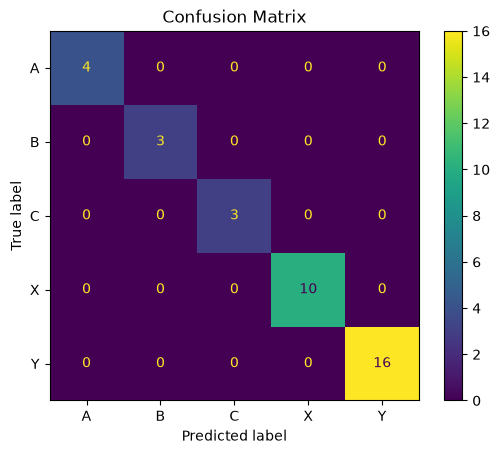

In [75]:
ConfusionMatrixDisplay.from_estimator(estimator = final_model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

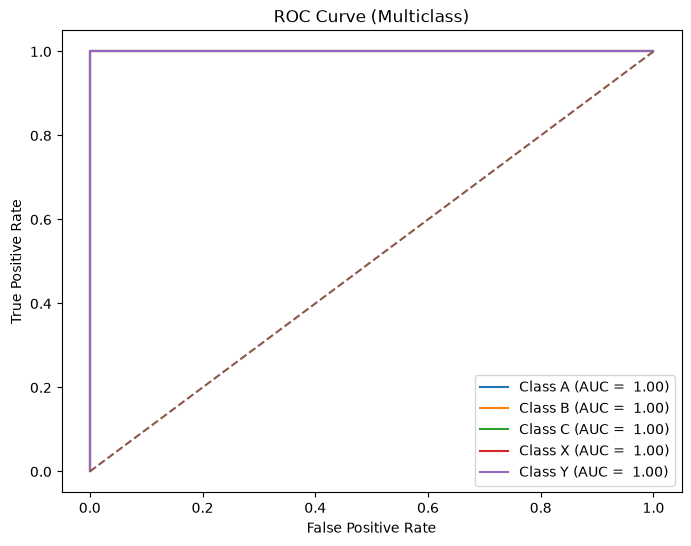

In [77]:
y_score = final_model.predict_proba(X_test)

classes = final_model.classes_

y_test_bin = label_binarize(y_test , classes = classes)

plt.figure(figsize = (8 , 6))

for i , cls in enumerate(classes):
    fpr , tpr , _ = roc_curve(y_test_bin[: , i] , y_score[: , i])
    roc_auc = auc(fpr , tpr)
    plt.plot(fpr , tpr , label = f"Class {cls} (AUC = {roc_auc : .2f})")

plt.plot([0 , 1] , [0 , 1] , "--")
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Plot Tree

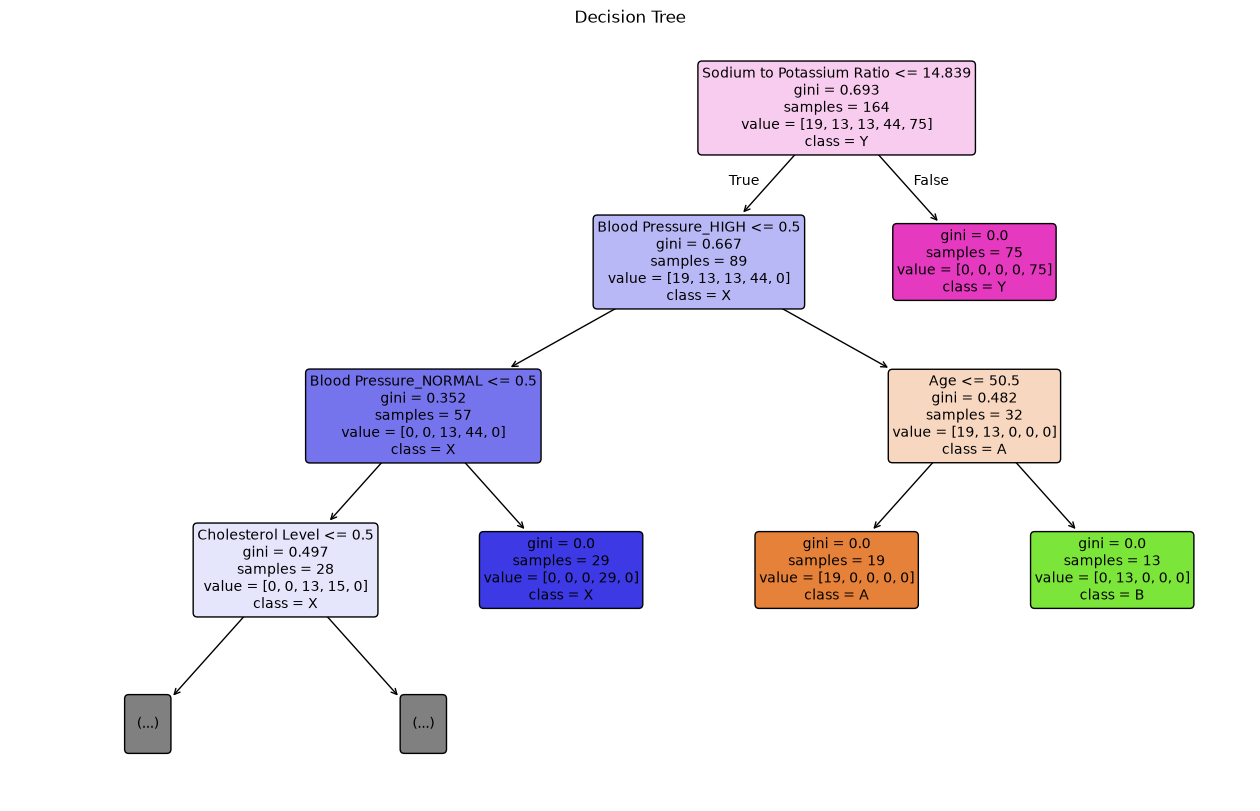

In [83]:
plt.figure(figsize = (16 , 10))
plot_tree(final_model , feature_names = X.columns , 
          class_names = final_model.classes_ , filled = True ,
          rounded = True , max_depth = 3 , fontsize = 10)
plt.title("Decision Tree")
plt.show()